In [2]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_dataset.csv to cleaned_dataset.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_dataset.csv")

df.head()

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.describe(include='object')

,name,sex,ticket,embarked
count,891,891,891,891
unique,891,2,681,3
top,"Dooley, Mr. Patrick",male,347082,S
freq,1,577,7,646


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   name      891 non-null    object 
 3   sex       891 non-null    object 
 4   age       891 non-null    float64
 5   sibsp     891 non-null    int64  
 6   parch     891 non-null    int64  
 7   ticket    891 non-null    object 
 8   fare      891 non-null    float64
 9   embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 69.7+ KB


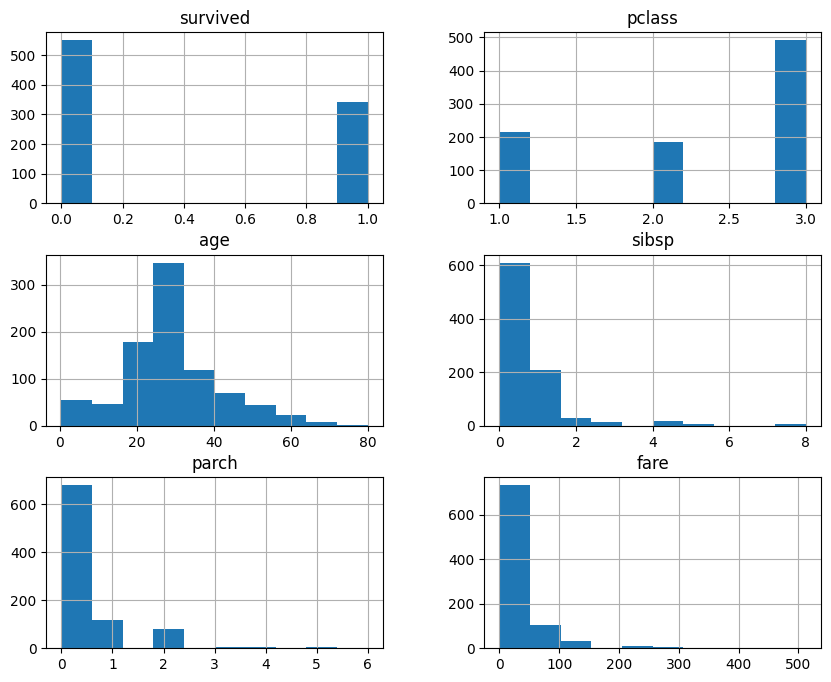

In [7]:
df.hist(figsize=(10,8))
plt.show()

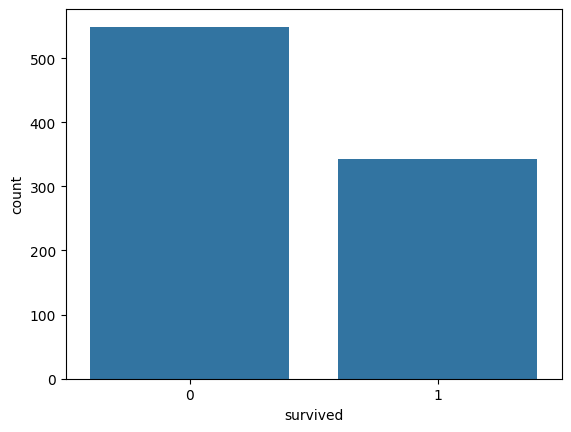

In [10]:
sns.countplot(x='survived', data=df)
plt.show()

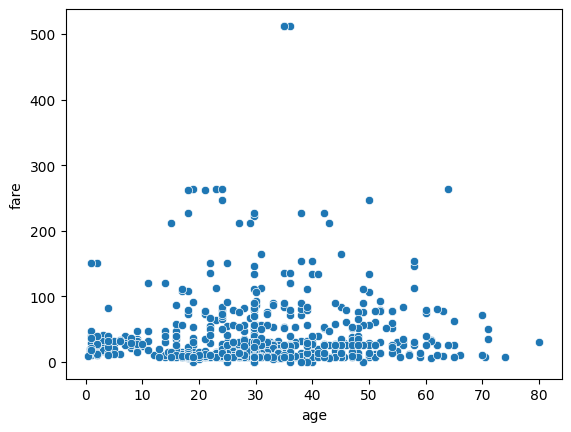

In [12]:
sns.scatterplot(x='age', y='fare', data=df)
plt.show()

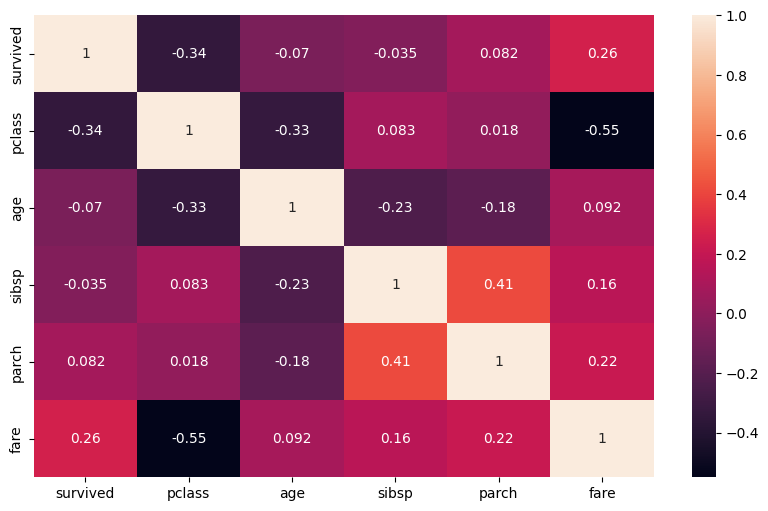

In [14]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.show()

In [15]:
!pip install ipython-sql


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.2 MB/s eta 0:00:00


In [16]:
%load_ext sql

In [18]:
%sql sqlite:///train.db

In [20]:
import pandas as pd

df = pd.read_csv("cleaned_dataset.csv")



In [22]:
import sqlite3

conn = sqlite3.connect("train.db")
df.to_sql("train", conn, if_exists="replace", index=False)

891

In [27]:
total_passengers_df = pd.read_sql_query("SELECT COUNT(*) AS Total_Passengers FROM train;", conn)
total_passengers_df

,Total_Passengers
0,891


In [29]:
survival_rate_df = pd.read_sql_query("SELECT AVG(survived)*100 AS Survival_Rate FROM train;", conn)
survival_rate_df

,Survival_Rate
0,38.383838


In [32]:
gender_survival_df = pd.read_sql_query("SELECT sex, AVG(survived)*100 AS Survival_Rate FROM train GROUP BY sex;", conn)
gender_survival_df

,sex,Survival_Rate
0,female,74.203822
1,male,18.890815


In [35]:
pclass_survival_df = pd.read_sql_query("SELECT pclass, AVG(survived)*100 AS Survival_Rate FROM train GROUP BY pclass;", conn)
pclass_survival_df

,pclass,Survival_Rate
0,1,62.962963
1,2,47.282609
2,3,24.236253


In [37]:
pclass_count_df = pd.read_sql_query("SELECT Pclass, COUNT(*) AS PassengerCount FROM train GROUP BY Pclass;", conn)
pclass_count_df

,pclass,PassengerCount
0,1,216
1,2,184
2,3,491
